# Global SHAP vs. visual distortion severity

Audio/Video-SHAP as a function of distortion severity level, mirroring Fig. 3 of the Dr. SHAP-AV paper (which sweeps SNR for audio). Here we sweep a visual distortion instead, holding audio clean.

Since `Audio-SHAP + Video-SHAP == 1` always (Eq. 6 of the paper), Video-SHAP is derived as `1 - Audio-SHAP` rather than logged separately.

In [1]:
import matplotlib.pyplot as plt

# Fixed per-distortion-type color identity, so a type keeps its color across
# plots even as more types are added (color follows the entity, not its rank).
DIST_TYPE_COLORS = {
    "GB": "#2a78d6",     # blue
    "JPEG": "#e34948",   # red
    "GNC": "#1baf7a",    # aqua
    "BW": "#eda100",     # yellow
    "CC": "#4a3aa7",     # violet
}


def plot_video_shap_severity(levels, audio_shap_by_type, model_name):
    """
    levels: x-axis tick labels, e.g. ["clean", "1", "2", "3", "4", "5"]
    audio_shap_by_type: dict of {dist_type: [Audio-SHAP fraction per level]},
        e.g. {"GB": [...], "JPEG": [...]}
    model_name: shown in the title
    """
    x = range(len(levels))
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for dist_type, audio_shap in audio_shap_by_type.items():
        video_shap = [1.0 - a for a in audio_shap]
        ax.plot(
            x, video_shap, marker="o", markersize=7, linewidth=2,
            color=DIST_TYPE_COLORS[dist_type], label=dist_type,
        )

    ax.set_xlabel("Distortion severity level")
    ax.set_ylabel("Video contribution (Video-SHAP)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(levels)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, title="Distortion type")

    ax.set_title(f"{model_name}: Video-SHAP vs. distortion severity")
    fig.tight_layout()
    return fig, ax

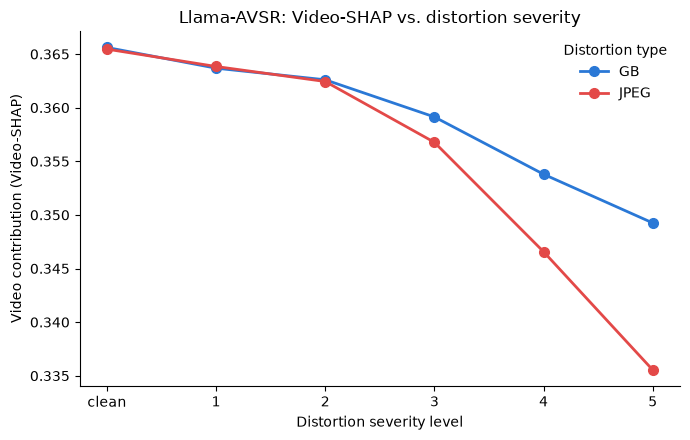

In [2]:
levels = ["clean", "1", "2", "3", "4", "5"]

audio_shap_llamaavsr_gb = [
    0.6343841552734375,   # clean
    0.636317789554596,    # lvl 1
    0.6373989582061768,   # lvl 2
    0.6408631801605225,   # lvl 3
    0.6462072730064392,   # lvl 4
    0.6507480144500732,   # lvl 5
]

audio_shap_llamaavsr_jpeg = [
    0.6345399022102356,   # clean
    0.6361595988273621,   # lvl 1
    0.6375601291656494,   # lvl 2
    0.6432302594184875,   # lvl 3
    0.6534318327903748,   # lvl 4
    0.6644567847251892,   # lvl 5
]

fig, ax = plot_video_shap_severity(
    levels,
    {"GB": audio_shap_llamaavsr_gb, "JPEG": audio_shap_llamaavsr_jpeg},
    model_name="Llama-AVSR",
)
plt.show()